# Do concept citation chains survive in new fields? A demo of the citation gate and viability labels

This notebook is a small, runnable version of the iteration-2 experiment **"Citation gate, viability labels and power check"** (artifact `art_yjFB8Spw2w6M`).
It uses only the CPU and makes no API calls.

**The question.** A scientific *concept* (for example "graphical lasso" or "polar code") is born in an **origin** subfield and later spreads into **host** subfields. Once it arrives in a host, does it *reproduce locally*? Do new host papers cite earlier host papers on the concept? Or is it kept alive only by citations *imported* from outside?

The orchestrator `method.py` runs two core stages, and this notebook runs both unchanged:

1. **Gate A.** For every host edge-year `(c, d, t)` it measures the **within-host, non-canonical traced share**: the share of the concept's new papers in subfield `d` (years `t-4..t`) that cite at least one earlier non-canonical concept paper *in the same host subfield*. Gate A passes if more than 50% of edges with `|Kd| >= 10` have a share of at least 0.40. **In the full run Gate A FAILS (17.3%)**, and the lenient any-parent share (0.48) overstates host transmission.
2. **Viability layer.** For every eligible edge it computes the local reproduction ratio `rho = sum(a)/|Pd|`, the import ratio `m`, and a benchmark `rho0(d,t)` from *stationary* reference concepts. It then runs a paper-cluster bootstrap (B reps) with BH-corrected one-sided tests per `(c, t)` family, and labels each edge **SOURCE / SINK / FADING / UNDETERMINED**.

The notebook loads a curated subset of the iteration-1 corpus: **30 main-arm concepts and 10 reference-arm concepts** (about 39k papers and 124k within-concept citations). The original code is kept as is. Each `src/` module appears verbatim in its own `%%writefile` cell, so `method.py`'s imports work unchanged. Only the loaders (`io_load.py`) and the path config (`common.py`) are adapted to read the demo JSON instead of the raw parquet corpus.

> The other stages of `method.py` (`origin`, `power`, `audit`, `synth`, `p1`, `figures`, `assemble`) need the full corpus, the pre-registration files and about 25 CPU-minutes, so this demo leaves them out.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, statsmodels, matplotlib, pyarrow, PyYAML — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0',
         'pyarrow==18.1.0', 'PyYAML==6.0.3')

## Imports

This is the original import block of `method.py`, plus `matplotlib` for the final plots. The original script did `sys.path.insert(0, <script dir>/src)`. Here the modules are written to a local `src/` folder by the cells below, so we insert that folder instead.

In [2]:
from __future__ import annotations

import json
import os

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")
import multiprocessing as mp
import pickle
import sys
import time
from concurrent.futures import ProcessPoolExecutor, as_completed
from pathlib import Path

Path("src").mkdir(exist_ok=True)
sys.path.insert(0, str(Path("src").resolve()))

import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from loguru import logger  # noqa: E402

import matplotlib.pyplot as plt  # notebook addition: final visualisation

## Data loading

The notebook loads `mini_demo_data.json` from GitHub and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_desxWCcMY1R1/round-2/experiment-2/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("concepts:", len(data["examples"]),
      "| main:", sum(e["arm"] == "main" for e in data["examples"]),
      "| reference:", sum(e["arm"] == "reference" for e in data["examples"]))
ex = data["examples"][0]
print("example concept:", ex["concept_id"], repr(ex["phrase"]), "F =", ex["F"], "origin subfield =", ex["origin_sub"],
      "| papers:", len(ex["papers"]["year"]), "| within-concept citations:", len(ex["cites"]))

Subset of the iteration-1 concept corpus (art_94GEMUsgAmgK) as prepared by io_load.prepare(): 30 main-arm + 10 reference-arm concepts, each with its de-duplicated c-papers (columnar) and within-concept citations (child_idx, parent_idx). 20 main concepts carry non-UNDETERMINED labels in the full run.
concepts: 40 | main: 30 | reference: 10
example concept: c_bf12df84c614 'superluminal neutrino' F = 2011 origin subfield = 3106 | papers: 177 | within-concept citations: 528


## Configuration

The original run read `seed`, `n_workers` and `B` from `config.yaml` and used **all 184 main and 22 reference concepts**. This cell sets the tunable parameters and writes them to `config.yaml`, which the unchanged `common.py` then reads.

| parameter | demo value | original |
|---|---|---|
| `B` (paper-cluster bootstrap reps, also REF_BOOT reps) | 1000 | 1000 |
| `N_MAIN_CONCEPTS` (main-arm concepts used, of 30 in the demo file) | 30 | 184 (full corpus) |
| `N_REF_CONCEPTS` (reference concepts behind the ρ0 benchmark, of 10) | 10 | 22 (full corpus) |
| `SEED` | 20261001 | 20261001 |
| `STAGES` | gate_a, viability | all |

In [5]:
B_REPS = 1000            # bootstrap replicates (original: 1000)
N_MAIN_CONCEPTS = 30     # main-arm concepts to use from the demo file (original: all 184 of the full corpus)
N_REF_CONCEPTS = 10      # reference-arm concepts to use from the demo file (original: all 22 of the full corpus)
SEED = 20261001          # original seed
N_WORKERS_CFG = 4        # original n_workers (method.py uses min(4, detected CPUs))
STAGES = ["gate_a", "viability"]   # original default: ["all"]

Path("config.yaml").write_text(
    f"seed: {SEED}\nn_workers: {N_WORKERS_CFG}\nB: {B_REPS}\n"
)
print(Path("config.yaml").read_text())

seed: 20261001
n_workers: 4
B: 1000



## `src/common.py`: shared paths, config and helpers

This is the original module with one change. The run-directory paths (`RUN`, `DS1`, `RESEARCH1`, `STRAT1`) pointed at the raw iteration-1 artifacts on the research server, so they are commented out. `WS` resolves to the notebook folder, so `results/`, `figures/` and `logs/` are created next to the notebook.

In [6]:
%%writefile src/common.py
"""Shared paths, config, logging and small helpers."""
from __future__ import annotations

import hashlib
import math
import os
import sys
from pathlib import Path

import yaml
from loguru import logger

WS = Path(__file__).resolve().parents[1]
CFG = yaml.safe_load((WS / "config.yaml").read_text())
# RUN = Path(os.environ.get("AII_RUN_DIR", WS.parents[3]))   # demo: raw corpus not available
# DS1 = Path(os.environ["AII_DS1_DIR"]) if os.environ.get("AII_DS1_DIR") else RUN / CFG["ds1"]
# RESEARCH1 = RUN / CFG["research1"]
# STRAT1 = RUN / CFG["strat1"]
SEED = int(CFG["seed"])
B = int(CFG["B"])
RESULTS = WS / "results"
FIGS = WS / "figures"
LOGS = WS / "logs"


def setup_logging(name: str) -> None:
    LOGS.mkdir(exist_ok=True)
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
    logger.add(LOGS / f"{name}.log", rotation="30 MB", level="DEBUG")


def h32(s: str) -> int:
    """Stable 32-bit hash of a string (for per-task seeds, independent of scheduling)."""
    return int(hashlib.sha1(s.encode()).hexdigest()[:8], 16)


def detect_cpus() -> int:
    try:
        parts = Path("/sys/fs/cgroup/cpu.max").read_text().split()
        if parts[0] != "max":
            return math.ceil(int(parts[0]) / int(parts[1]))
    except (FileNotFoundError, ValueError, IndexError):
        pass
    try:
        q = int(Path("/sys/fs/cgroup/cpu/cpu.cfs_quota_us").read_text())
        p = int(Path("/sys/fs/cgroup/cpu/cpu.cfs_period_us").read_text())
        if q > 0:
            return math.ceil(q / p)
    except (FileNotFoundError, ValueError):
        pass
    try:
        return len(os.sched_getaffinity(0))
    except (AttributeError, OSError):
        return os.cpu_count() or 1


def set_ram_limit(gb: float) -> None:
    import resource
    b = int(gb * 1024**3)
    resource.setrlimit(resource.RLIMIT_AS, (b, b))


def f_band(F: int) -> str:
    return "2005-07" if F <= 2007 else ("2008-11" if F <= 2011 else "2012-16")

Writing src/common.py


## `src/io_load.py`: loaders (adapted to the demo JSON)

The original `prepare()` read `data_out.json`, `concept_work.parquet` and four `works_part_*.parquet` files (208k works). It built the within-concept citation table, the lenient flags and the de-duplicated per-concept tables, then cached them in `results/cache/prepared.pkl`. `mini_demo_data.json` already contains **the output of that `prepare()`** for 40 concepts, in the same schema:

- `papers`: `work_id, year, sub, field, n_refs, cbc (2026 cited_by_count), n_kw, lenient_excl_F`, sorted by `(year, work_id)`;
- `cites`: `(child_idx, parent_idx)` pairs for every in-concept citation;
- `kw`: keyword indices. These are stored only for papers in a subfield's *entry year*, which is the only place `graft_fallback()` reads them.

`prepare_from_data()` rebuilds the same dict and writes the same pickle cache. The unchanged `prepare()` then serves it to the main process and to the spawned worker processes. The link-level (no-dedup) table `links_lenient` is **not** in the demo file, so the iteration-1 lenient loader check is skipped.

In [7]:
%%writefile src/io_load.py

"""Loaders (DEMO VERSION). The original read the iteration-1 dataset artifact (DS1) parquet files; here the
per-concept structure produced by the original prepare() is rebuilt from mini_demo_data.json.

prepare() returns, per concept:
  papers  : DataFrame (dedup'ed c-papers) work_id, year, sub, field, n_refs, cbc, n_kw, lenient_excl_F
  cites   : int32 array (n, 2) of (child_idx, parent_idx) for every in-cset citation child -> parent, parent != child
            (no year / canonical filter; lineage.py applies those)
"""
from __future__ import annotations

import pickle

import numpy as np
import pandas as pd
from loguru import logger

from common import RESULTS

CACHE = RESULTS / "cache" / "prepared.pkl"

CONCEPT_COLS = ["concept_id", "phrase", "arm", "fold", "route", "flags", "sense_share", "sense_check_fail", "F", "V",
                "F_band", "volume_tercile", "origin_sub", "origin_field"]


def load_concepts(data: dict, n_main: int, n_ref: int) -> pd.DataFrame:
    exs = [e for e in data["examples"] if e["arm"] == "main"][:n_main] + \
          [e for e in data["examples"] if e["arm"] == "reference"][:n_ref]
    df = pd.DataFrame([{k: e[k] for k in CONCEPT_COLS} for e in exs])
    logger.info(f"D1 concepts: {len(df)} ({(df.arm == 'main').sum()} main, {(df.arm == 'reference').sum()} reference)")
    return df


def load_taxonomy(data: dict) -> dict:
    return {"sub_field": {int(k): int(v) for k, v in data["subfield_field"].items()}}


def load_totals(variant: str = "all_types") -> dict[tuple[int, int], int]:
    return prepare()["totals"]


def prepare_from_data(data: dict, n_main: int, n_ref: int) -> dict:
    """Rebuild the original prepare() output from the demo JSON and write the same pickle cache."""
    concepts = load_concepts(data, n_main, n_ref)
    keep = set(concepts.concept_id)
    per, kw = {}, {}
    for e in data["examples"]:
        if e["concept_id"] not in keep:
            continue
        p = e["papers"]
        papers = pd.DataFrame({
            "work_id": np.asarray(p["work_id"], np.int64), "year": np.asarray(p["year"], np.int32),
            "sub": np.asarray(p["sub"], np.int32), "field": np.asarray(p["field"], np.int32),
            "n_refs": np.asarray(p["n_refs"], np.int32), "cbc": np.asarray(p["cbc"], np.int64),
            "n_kw": np.asarray(p["n_kw"], np.int32), "lenient_excl_F": np.asarray(p["lenient_excl_F"], bool)})
        arr = np.asarray(e["cites"], np.int32).reshape(-1, 2)
        per[e["concept_id"]] = {"papers": papers, "cites": arr}
        kw[e["concept_id"]] = [np.asarray(e["kw_entry"].get(str(i), []), np.int32) for i in range(len(papers))]
    totals = {(int(sf), int(y)): int(n) for sf, y, n in data["subfield_year_totals"]}
    out = {"concepts": concepts, "tax": load_taxonomy(data), "per": per, "kw": kw, "totals": totals}
    CACHE.parent.mkdir(parents=True, exist_ok=True)
    CACHE.write_bytes(pickle.dumps(out, protocol=5))
    logger.info(f"prepared cache written ({CACHE.stat().st_size / 1e6:.1f} MB); concepts with papers: {len(per)}")
    return out


def prepare(force: bool = False) -> dict:
    if CACHE.exists() and not force:
        return pickle.loads(CACHE.read_bytes())
    raise FileNotFoundError("run io_load.prepare_from_data(data, ...) first")

Writing src/io_load.py


## `src/leakage.py`: the W1 leakage guard

Every edge-year function receives only a `W1View`. This view holds the concept's papers with `year <= t` and the citations whose two endpoints are both inside the view. So no statistic for year `t` can use a paper from after `t`. (The original has a mutation test showing that injected post-`t` papers leave every output byte-identical.)

In [8]:
%%writefile src/leakage.py
"""Leakage guard. Every edge-year function accepts ONLY a W1View and asserts its t_max.

origin.py is the only module allowed to read c-papers with year > t (and only origin-subfield rows).
"""
from __future__ import annotations

from dataclasses import dataclass

import numpy as np
import pandas as pd


@dataclass(frozen=True)
class W1View:
    papers: pd.DataFrame      # c-papers with year <= t (row order = original order, prefix of a year-sorted table)
    cites: np.ndarray         # (child_idx, parent_idx) with BOTH endpoints inside the view
    t_max: int
    n_total: int              # rows in the underlying table (only used for mapping, never for statistics)


def w1_view(cdata: dict, t: int) -> W1View:
    p = cdata["papers"]
    keep = (p["year"].to_numpy() <= t)
    idx = np.flatnonzero(keep)
    remap = -np.ones(len(p), np.int64)
    remap[idx] = np.arange(len(idx))
    view = p.iloc[idx].reset_index(drop=True).copy()
    view.attrs["t_max"] = t
    c = cdata["cites"]
    if len(c):
        ok = keep[c[:, 0]] & keep[c[:, 1]]
        cc = np.stack([remap[c[ok, 0]], remap[c[ok, 1]]], axis=1).astype(np.int64)
    else:
        cc = np.zeros((0, 2), np.int64)
    v = W1View(papers=view, cites=cc, t_max=t, n_total=len(p))
    check_view(v, t)
    return v


def check_view(v: W1View, t: int) -> None:
    assert isinstance(v, W1View), "edge-year functions accept only a W1View"
    assert v.t_max == t, f"view t_max {v.t_max} != t {t}"
    assert v.papers.attrs.get("t_max") == t
    if len(v.papers):
        assert int(v.papers["year"].max()) <= t, "view contains papers after t"

Writing src/leakage.py


## `src/lineage.py`: canonical routing, parentage and per-edge vectors

For an edge `(c, d, t)`:

- **Canonical papers** are the F-year papers plus the top-5 by cited_by_count. They are routed away: a child whose only in-concept parents are canonical counts as *background-only*, not traced.
- **Parentage weights** `w_kp ∝ exp(-(year_k - year_p)/τ)` with τ = 2 are normalised over each child's non-canonical parents.
- **Cohort parents** `Pd` are non-canonical d-papers from years `t-5..t-3`. **Children** `Kd` are d-papers from years `t-4..t`.
- **`a`** is the weighted local reproduction from cohort parents, **`imp`** the weighted imports from other subfields, and **`tr`** marks traced children.
- `rho = Σa / |Pd|` and `m = Σimp / Σtr`. The Gate-A statistic `within_host_share` is the share of children with at least one non-canonical parent in `d` dated `>= t-5`.
- `momentum()` gives the W1 growth baseline: an OLS slope of log share on year.

In [9]:
%%writefile src/lineage.py
"""Parentage, per-edge vectors (a, b, imp, tr), rho / m point estimates, Gate-A shares, W1 momentum.

All edge-year functions take a W1View (leakage.py) and never see papers dated after t.
"""
from __future__ import annotations

from dataclasses import dataclass

import numpy as np
import pandas as pd
from scipy import stats

from leakage import W1View, check_view

TAU = 2.0  # parent-age decay of w_kp


def canonical_main(papers: pd.DataFrame, F: int | None, top: int = 5) -> set[int]:
    """F-year c-papers plus top-5 by 2026 cited_by_count (ties -> lower work_id). The only declared post-t input."""
    s = papers.sort_values(["cbc", "work_id"], ascending=[False, True])
    canon = set(s.work_id.head(top).tolist())
    if F is not None:
        canon |= set(papers.work_id[papers.year == F].tolist())
    return canon


def canonical_w1(view: W1View, F: int | None, t: int, top: int = 5) -> set[int]:
    """CANON_W1 sensitivity: F-year papers + top-5 by in-concept citations received from c-papers with year <= t."""
    check_view(view, t)
    p = view.papers
    cnt = np.bincount(view.cites[:, 1], minlength=len(p)) if len(view.cites) else np.zeros(len(p), int)
    s = pd.DataFrame({"work_id": p.work_id, "n": cnt}).sort_values(["n", "work_id"], ascending=[False, True])
    canon = set(s.work_id.head(top).tolist())
    if F is not None:
        canon |= set(p.work_id[p.year == F].tolist())
    return canon


@dataclass
class Parentage:
    ch: np.ndarray        # child idx per valid cite
    pa: np.ndarray        # parent idx per valid cite
    w: np.ndarray         # normalised weight per valid cite
    traced: np.ndarray    # bool per paper
    bg_only: np.ndarray   # bool per paper: has cset parents (year <= own) but all canonical
    canon: np.ndarray     # bool per paper


def parentage(view: W1View, canon_ids: set[int], t: int) -> Parentage:
    check_view(view, t)
    p = view.papers
    n = len(p)
    yr = p.year.to_numpy()
    canon = p.work_id.isin(canon_ids).to_numpy()
    c = view.cites
    if len(c):
        ch, pa = c[:, 0], c[:, 1]
        base = (pa != ch) & (yr[pa] <= yr[ch])
        ch, pa = ch[base], pa[base]
    else:
        ch = pa = np.zeros(0, np.int64)
    has_any = np.zeros(n, bool)
    has_any[ch] = True
    v = ~canon[pa]
    ch, pa = ch[v], pa[v]
    raw = np.exp(-(yr[ch] - yr[pa]) / TAU)
    tot = np.bincount(ch, weights=raw, minlength=n)
    w = raw / tot[ch] if len(ch) else raw
    traced = np.zeros(n, bool)
    traced[ch] = True
    return Parentage(ch=ch, pa=pa, w=w, traced=traced, bg_only=has_any & ~traced, canon=canon)


@dataclass
class EdgeVec:
    units: np.ndarray     # paper idx of Pd union Kd
    a: np.ndarray
    b: np.ndarray
    imp: np.ndarray
    tr: np.ndarray
    n_parents: int
    n_children: int
    n_w1: int
    stats: dict


def edge_vectors(view: W1View, par: Parentage, d: int, t: int) -> EdgeVec:
    """Vectors for edge (c, d, t) using only W1 papers (years <= t)."""
    check_view(view, t)
    p = view.papers
    yr = p.year.to_numpy()
    sub = p["sub"].to_numpy()
    isd = sub == d
    Pd = isd & ~par.canon & (yr >= t - 5) & (yr <= t - 3)
    Kd = isd & (yr >= t - 4) & (yr <= t)
    n_w1 = int((isd & (yr >= t - 5)).sum())
    n = len(p)
    ch, pa, w = par.ch, par.pa, par.w
    inK = Kd[ch]
    a = np.bincount(ch[inK & Pd[pa]], weights=w[inK & Pd[pa]], minlength=n)
    imp_sel = inK & (sub[pa] != d)
    imp = np.bincount(ch[imp_sel], weights=w[imp_sel], minlength=n)
    tr = (par.traced & Kd).astype(float)
    # Gate-A within-host: child in Kd citing >= 1 non-canonical parent in d with year in [t-5, year_k]
    wh_sel = inK & (sub[pa] == d) & (yr[pa] >= t - 5)
    within = np.zeros(n, bool)
    within[ch[wh_sel]] = True
    units = np.flatnonzero(Pd | Kd)
    nK = int(Kd.sum())
    nrefs = p.n_refs.to_numpy()
    kref = Kd & (nrefs > 0)
    st = {
        "within_host_share": float(within[Kd].mean()) if nK else np.nan,
        "within_host_share_refs": float(within[kref].mean()) if kref.any() else np.nan,
        "n_children_with_refs": int(kref.sum()),
        "lenient_share": float(p.lenient_excl_F.to_numpy()[Kd].mean()) if nK else np.nan,
        "n_traced": int(par.traced[Kd].sum()),
        "untraced_share": float(1 - par.traced[Kd].mean()) if nK else np.nan,
        "background_only_share": float(par.bg_only[Kd].mean()) if nK else np.nan,
        "n_canonical_in_d": int((isd & par.canon).sum()),
    }
    return EdgeVec(units=units, a=a[units], b=Pd[units].astype(float), imp=imp[units], tr=tr[units],
                   n_parents=int(Pd.sum()), n_children=nK, n_w1=n_w1, stats=st)


def point_estimates(ev: EdgeVec) -> dict:
    rho = ev.a.sum() / ev.b.sum() if ev.b.sum() > 0 else np.nan
    m = ev.imp.sum() / ev.tr.sum() if ev.tr.sum() > 0 else np.nan
    return {"rho": float(rho), "m": float(m)}


def momentum(counts: np.ndarray, totals: np.ndarray, years: np.ndarray) -> tuple[float, float, float]:
    """OLS slope of log(1e4*n/T + 1e-3) on year, with 90% CI (t, df = k-2)."""
    ok = totals > 0
    y = np.log(1e4 * counts[ok] / totals[ok] + 1e-3)
    x = years[ok].astype(float)
    if len(x) < 3:
        return np.nan, np.nan, np.nan
    r = stats.linregress(x, y)
    q = stats.t.ppf(0.95, len(x) - 2)
    return float(r.slope), float(r.slope - q * r.stderr), float(r.slope + q * r.stderr)


def w1_counts(view: W1View, t: int) -> pd.Series:
    """W1 (years t-5..t) c-paper counts per subfield (unknown subfield = -1 dropped)."""
    check_view(view, t)
    p = view.papers
    s = p["sub"][(p.year >= t - 5) & (p["sub"] >= 0)]
    return s.value_counts()


def yearly_counts(view: W1View, d: int, t: int) -> np.ndarray:
    check_view(view, t)
    p = view.papers
    yrs = p.year[p["sub"] == d].to_numpy()
    return np.array([(yrs == y).sum() for y in range(t - 5, t + 1)], float)

Writing src/lineage.py


## `src/labels.py`: paper-cluster bootstrap, BH families and the four states

`bootstrap_edge` resamples the edge's papers, i.e. the rows of `(a, b, imp, tr)`, with multinomial counts. It returns percentile CIs for `rho`, `m` and `rho~ = rho/rho0`, and one-sided bootstrap p-values for `rho~ > 1` and `rho~ < 1`. `assign_states` runs BH (q = 0.10) inside each `(concept, t)` family of *tested* edges (`|Kd| >= n_min`):

- **SOURCE**: significantly above the benchmark;
- **SINK**: significantly below, with `m_lo > 0.5` (sustained by imports);
- **FADING**: significantly below, without imports;
- **UNDETERMINED**: everything else.

`nmin_rule` picks the smallest n_min bin above which the median log-ρ CI width is at most 0.7. If no bin meets this, it falls back to 30, which is what happened in the full run.

In [10]:
%%writefile src/labels.py
"""Paper-cluster bootstrap, BH families, four states, n_min rule."""
from __future__ import annotations

import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests

from lineage import EdgeVec

Q_BH = 0.10
M_SINK = 0.5
NMIN_BINS = [5, 10, 15, 20, 30]
WIDTH_MAX = 0.7


def boot_counts(rng: np.random.Generator, n: int, B: int) -> np.ndarray:
    """B x n multinomial(n, 1/n) counts via bincount of uniform index draws (identical distribution)."""
    idx = rng.integers(0, n, size=(B, n), dtype=np.int64)
    idx += (np.arange(B, dtype=np.int64) * n)[:, None]
    return np.bincount(idx.ravel(), minlength=B * n).reshape(B, n).astype(np.float64)


def bootstrap_edge(ev: EdgeVec, rng: np.random.Generator, B: int, rho0: dict[str, object]) -> dict:
    """rho0: variant name -> float (fixed benchmark) or ndarray (B,) (REF_BOOT). Returns CIs and p-values."""
    n = len(ev.units)
    V = np.stack([ev.a, ev.b, ev.imp, ev.tr], axis=1)
    S = np.zeros((B, 4))
    chunk = max(1, int(2e7 // max(n, 1)))
    for s0 in range(0, B, chunk):
        bb = min(chunk, B - s0)
        S[s0:s0 + bb] = boot_counts(rng, n, bb) @ V
    sa, sb, si, st = S.T
    with np.errstate(divide="ignore", invalid="ignore"):
        rs = np.where(sb > 0, sa / sb, np.nan)
        ms = np.where(st > 0, si / st, np.nan)
        lr = np.where(sb > 0, np.where(sa > 0, np.log(sa / sb), np.log((sa + 0.5) / (sb + 0.5))), np.nan)
    out = {"nan_share": float(np.isnan(rs).mean())}
    ok = ~np.isnan(rs)
    if ok.sum() >= 10:
        out["rho_lo"], out["rho_hi"] = (float(x) for x in np.percentile(rs[ok], [5, 95]))
        l5, l95 = np.percentile(lr[ok], [5, 95])
        out["log_ci_width"] = float(l95 - l5)
    else:
        out["rho_lo"] = out["rho_hi"] = out["log_ci_width"] = np.nan
    okm = ~np.isnan(ms)
    if okm.sum() >= 10:
        out["m_lo"], out["m_hi"] = (float(x) for x in np.percentile(ms[okm], [5, 95]))
    else:
        out["m_lo"] = out["m_hi"] = np.nan
    for name, r0 in rho0.items():
        r0a = np.asarray(r0, float)
        if np.all(np.isnan(r0a)):
            out[f"p_greater_{name}"] = out[f"p_less_{name}"] = 1.0
            out[f"rt_lo_{name}"] = out[f"rt_hi_{name}"] = np.nan
            continue
        with np.errstate(divide="ignore", invalid="ignore"):
            rt = rs / r0a
        bad = np.isnan(rt)
        out[f"p_greater_{name}"] = float((1 + np.sum(bad | (rt <= 1))) / (B + 1))
        out[f"p_less_{name}"] = float((1 + np.sum(bad | (rt >= 1))) / (B + 1))
        if (~bad).sum() >= 10:
            out[f"rt_lo_{name}"], out[f"rt_hi_{name}"] = (float(x) for x in np.percentile(rt[~bad], [5, 95]))
        else:
            out[f"rt_lo_{name}"] = out[f"rt_hi_{name}"] = np.nan
    return out


def bh_reject(p: np.ndarray, q: float = Q_BH) -> np.ndarray:
    if len(p) == 0:
        return np.zeros(0, bool)
    return multipletests(p, alpha=q, method="fdr_bh")[0]


def bh_qvalues(p: np.ndarray) -> np.ndarray:
    if len(p) == 0:
        return np.zeros(0)
    return multipletests(p, alpha=Q_BH, method="fdr_bh")[1]


def state_of(rej_g: bool, rej_l: bool, m_lo: float) -> str:
    if rej_g and not rej_l:
        return "SOURCE"
    if rej_l and not rej_g:
        return "SINK" if (m_lo is not None and not np.isnan(m_lo) and m_lo > M_SINK) else "FADING"
    return "UNDETERMINED"


def assign_states(df: pd.DataFrame, n_min: int, pg: str, pl: str, col: str) -> pd.DataFrame:
    """BH per (concept, t) family among tested edges; writes df[col] (state) and q-values for this variant."""
    tested = ((df.n_children >= n_min) & (df.n_parents >= 1) & (df.n_traced >= 1) & df.eligible).to_numpy()
    st = np.array(["UNDETERMINED"] * len(df), dtype=object)
    qg = np.full(len(df), np.nan)
    ql = np.full(len(df), np.nan)
    sub = df[tested]
    for _, g in sub.groupby(["concept_id", "t"]).groups.items():
        ii = df.index.get_indexer(g)
        p1 = df[pg].to_numpy()[ii]
        p2 = df[pl].to_numpy()[ii]
        r1, r2 = bh_reject(p1), bh_reject(p2)
        qg[ii], ql[ii] = bh_qvalues(p1), bh_qvalues(p2)
        mlo = df["m_lo"].to_numpy()[ii]
        for k, i in enumerate(ii):
            st[i] = state_of(bool(r1[k]), bool(r2[k]), mlo[k])
    df[col] = st
    return df.assign(**{f"{col}__q_greater": qg, f"{col}__q_less": ql, f"{col}__tested": tested})


def reason_code(row: pd.Series, n_min: int) -> str:
    if not row.eligible:
        return "ineligible_lt10_w1"
    if row.n_parents < 1:
        return "no_cohort_parents"
    if row.n_children < n_min:
        return "below_nmin"
    if row.n_traced < 1:
        return "no_traced_children"
    return "tested"


def nmin_rule(df: pd.DataFrame) -> dict:
    e = df[df.eligible & (df.n_children >= 5) & df.log_ci_width.notna()]
    edges = NMIN_BINS + [np.inf]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        s = e[(e.n_children >= lo) & (e.n_children < hi)].log_ci_width
        rows.append({"bin_lo": lo, "bin_hi": None if np.isinf(hi) else hi, "n_edges": int(len(s)),
                     "median_width": float(s.median()) if len(s) else None})
    ok = [r["median_width"] is not None and r["median_width"] <= WIDTH_MAX for r in rows]
    n_rule, flagged = None, False
    for i, r in enumerate(rows):
        if all(ok[i:]) and rows[i]["n_edges"] > 0:
            n_rule = r["bin_lo"]
            break
    if n_rule is None:
        n_rule, flagged = 30, True
    return {"bins": rows, "n_min_rule": int(n_rule), "rule_not_met_flag": flagged, "n_min_main": int(max(10, n_rule))}

Writing src/labels.py


## `src/benchmark.py`: the replacement benchmark ρ0(d, t)

Reference concepts are the "normal" concepts of the corpus. Their `(d, t)` cells are *stationary* if `n_w1 >= 30` and the |momentum slope| is below 0.05. `rho0(d,t)` is the median `rho` over the first level of the hierarchy with at least 3 cells and a positive median: **L1** same `(d,t)`, then **L2** same field and year, **L3** same field with `t ± 2`, **L4** same year, and **L5** all cells. The sensitivity variants are **EB** (log-scale empirical-Bayes shrinkage), **REF_BOOT** (reference concepts resampled in each of the B reps), past-only L3, and 3 references only.

In [11]:
%%writefile src/benchmark.py
"""Replacement benchmark rho0(d,t) from stationary reference cells via the pre-declared pooling hierarchy."""
from __future__ import annotations

import numpy as np
import pandas as pd

SLOPE_MAX = 0.05
MIN_W1 = 30
MIN_CELLS = 3


def stationary_cells(refs: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    c = refs[(refs.n_w1 >= MIN_W1) & (refs.slope.abs() < SLOPE_MAX) & refs.rho.notna() & (refs.n_parents >= 1)]
    if len(c):
        return c.copy(), "stationary"
    c = refs[(refs.n_w1 >= MIN_W1) & refs.is_modal & refs.rho.notna() & (refs.n_parents >= 1)]  # F2(b)
    if len(c):
        return c.copy(), "relaxed_modal_any_slope"
    return refs[(refs.n_w1 >= MIN_W1) & refs.rho.notna() & (refs.n_parents >= 1)].copy(), "relaxed_any"


def _med(v: np.ndarray) -> float:
    return float(np.median(v)) if len(v) >= MIN_CELLS else np.nan


def rho0_table(cells: pd.DataFrame, needed: list[tuple[int, int]], field_of: dict[int, int],
               l3_window: tuple[int, int] = (-2, 2)) -> dict[tuple[int, int], tuple[float, str, int]]:
    """(d,t) -> (rho0, level, n_cells). Levels L1..L5; a level is skipped if its median <= 0 or n < 3."""
    c = cells.assign(f=cells.d.map(lambda x: field_of.get(int(x), -1)))
    rho = c.rho.to_numpy()
    by_dt = {k: rho[v] for k, v in c.groupby(["d", "t"]).indices.items()}
    by_ft = {k: rho[v] for k, v in c.groupby(["f", "t"]).indices.items()}
    by_t = {k: rho[v] for k, v in c.groupby("t").indices.items()}
    allv = rho
    fs = c.f.to_numpy()
    ts = c.t.to_numpy()
    cache_l3: dict = {}
    out = {}
    for d, t in needed:
        f = field_of.get(int(d), -1)
        cand = []
        v1 = by_dt.get((d, t), np.zeros(0))
        cand.append(("L1", v1))
        cand.append(("L2", by_ft.get((f, t), np.zeros(0))))
        key = (f, t)
        if key not in cache_l3:
            sel = (fs == f) & (ts >= t + l3_window[0]) & (ts <= t + l3_window[1])
            cache_l3[key] = rho[sel]
        cand.append(("L3", cache_l3[key]))
        cand.append(("L4", by_t.get(t, np.zeros(0))))
        cand.append(("L5", allv))
        res = (np.nan, "none", 0)
        for lev, v in cand:
            m = _med(v)
            if not np.isnan(m) and m > 0:
                res = (m, lev, int(len(v)))
                break
        out[(d, t)] = res
    return out


def eb_table(cells: pd.DataFrame, needed: list[tuple[int, int]], field_of: dict[int, int],
             fallback: dict) -> dict[tuple[int, int], float]:
    """EB: cell mean of log rho_r (positive values) shrunk toward the field mean with MoM tau^2."""
    c = cells[cells.rho > 0].assign(f=cells.d.map(lambda x: field_of.get(int(x), -1)), x=lambda z: np.log(z.rho))
    g = c.groupby(["d", "t"]).x.agg(["mean", "var", "count"]).reset_index()
    s2_pool = float(np.nanmean(g["var"])) if g["var"].notna().any() else float(c.x.var())
    g["f"] = g.d.map(lambda x: field_of.get(int(x), -1))
    out = {}
    fstat = {}
    for f, gg in g.groupby("f"):
        if len(gg) >= 2:
            mu = float(gg["mean"].mean())
            tau2 = max(0.0, float(gg["mean"].var()) - float(np.mean(s2_pool / gg["count"])))
            fstat[f] = (mu, tau2)
    gi = g.set_index(["d", "t"])
    for d, t in needed:
        f = field_of.get(int(d), -1)
        if (d, t) in gi.index and f in fstat:
            r = gi.loc[(d, t)]
            mu, tau2 = fstat[f]
            wgt = tau2 / (tau2 + s2_pool / r["count"]) if (tau2 + s2_pool / r["count"]) > 0 else 0.0
            out[(d, t)] = float(np.exp(mu + wgt * (r["mean"] - mu)))
        else:
            out[(d, t)] = fallback[(d, t)][0]
    return out


def refboot_table(cells: pd.DataFrame, needed: list[tuple[int, int]], field_of: dict[int, int], B: int,
                  seed: int) -> dict[tuple[int, int], np.ndarray]:
    """REF_BOOT: resample reference concepts with replacement in each rep and recompute the hierarchy."""
    rng = np.random.default_rng([seed, 99])
    refs = np.array(sorted(cells.ref_id.unique()))
    out = {k: np.full(B, np.nan) for k in needed}
    by_ref = {r: g for r, g in cells.groupby("ref_id")}
    for b in range(B):
        draw = rng.choice(refs, size=len(refs), replace=True)
        cb = pd.concat([by_ref[r] for r in draw], ignore_index=True)
        tb = rho0_table(cb, needed, field_of)
        for k, v in tb.items():
            out[k][b] = v[0]
    return out

Writing src/benchmark.py


## `src/edges.py`: per-concept workers

`reference_concept` computes `rho_r(d,t)` for every reference cell, t = 2008–2019. `main_concept` loops over the focal years `t = F+3 … F+8` (up to 2019) and every subfield with at least 10 W1 papers, and builds one row per edge. With `boot=True` it also runs the bootstrap against every ρ0 variant and the CANON_W1 routing sensitivity. The bootstrap seed is `(SEED, sha1(concept), t, d)`, so results do not depend on worker scheduling.

In [12]:
%%writefile src/edges.py
"""Per-concept edge computation shared by Gate A (no bootstrap) and the viability layer (bootstrap).

Workers are spawned with the prepared cache loaded once per process (initializer).
"""
from __future__ import annotations

import numpy as np
import pandas as pd

from common import B as B_DEFAULT
from common import SEED, h32
from labels import bootstrap_edge
from leakage import w1_view
from lineage import canonical_main, canonical_w1, edge_vectors, momentum, parentage, point_estimates, w1_counts, yearly_counts

_G: dict = {}
REF_YEARS = list(range(2008, 2020))


def init_worker(payload: dict) -> None:
    import io_load
    d = io_load.prepare()
    _G.update(d)
    _G.update(payload)


def focal_years(F: int) -> list[int]:
    return [t for t in range(F + 3, F + 9) if t <= 2019]


def _mom(view, d, t, totals) -> tuple[float, float, float]:
    cnt = yearly_counts(view, d, t)
    yrs = np.arange(t - 5, t + 1)
    tot = np.array([totals.get((int(d), int(y)), 0) for y in yrs], float)
    return momentum(cnt, tot, yrs)


def modal_sub_2000_2004(papers: pd.DataFrame) -> int | None:
    s = papers["sub"][(papers.year >= 2000) & (papers.year <= 2004) & (papers["sub"] >= 0)]
    return int(s.value_counts().idxmax()) if len(s) else None


def reference_concept(cid: str, cdata: dict, totals: dict) -> list[dict]:
    """rho_r(d,t) for every (d,t) with >= 10 W1 d-papers, t = 2008..2019, origin NOT excluded; Gate-A ref stats."""
    papers = cdata["papers"]
    canon = canonical_main(papers, None)
    modal = modal_sub_2000_2004(papers)
    rows = []
    for t in REF_YEARS:
        view = w1_view(cdata, t)
        par = parentage(view, canon, t)
        cnt = w1_counts(view, t)
        for d, nw in cnt.items():
            if nw < 10:
                continue
            ev = edge_vectors(view, par, int(d), t)
            pe = point_estimates(ev)
            sl, lo, hi = _mom(view, int(d), t, totals)
            rows.append({"ref_id": cid, "d": int(d), "t": t, "n_w1": ev.n_w1, "n_children": ev.n_children,
                         "n_parents": ev.n_parents, "rho": pe["rho"], "m": pe["m"], "slope": sl,
                         "is_modal": modal is not None and int(d) == modal, "modal_sub": modal, **ev.stats})
    return rows


def main_concept(cid: str, *, boot: bool, B: int | None = None, rho0: dict | None = None,
                 rho0_boot: dict | None = None, canon_w1: bool = True, data: dict | None = None) -> dict:
    """All edges (c, d, t) for a main concept. rho0: variant -> {(d,t): value}; rho0_boot: {(d,t): ndarray(B)}."""
    G = data if data is not None else _G
    B = B or B_DEFAULT
    meta = G["concepts"].set_index("concept_id").loc[cid]
    cdata = G["per"][cid]
    totals = G["totals"]
    F, o = int(meta.F), (int(meta.origin_sub) if pd.notna(meta.origin_sub) else -999)
    papers = cdata["papers"]
    canon = canonical_main(papers, F)
    rows, ct = [], []
    for t in focal_years(F):
        view = w1_view(cdata, t)
        par = parentage(view, canon, t)
        cnt = w1_counts(view, t)
        ct.append({"concept_id": cid, "t": t, "counts": {int(k): int(v) for k, v in cnt.items()}})
        par_w1 = None
        for d, nw in cnt.items():
            d = int(d)
            if nw < 10:
                continue
            ev = edge_vectors(view, par, d, t)
            pe = point_estimates(ev)
            sl, slo, shi = _mom(view, d, t, totals)
            row = {"concept_id": cid, "t": t, "age": t - F, "d": d, "role": "origin" if d == o else "host",
                   "n_w1": ev.n_w1, "n_children": ev.n_children, "n_parents": ev.n_parents, "eligible": True,
                   "rho": pe["rho"], "m": pe["m"], "mom": sl, "mom_lo": slo, "mom_hi": shi,
                   "t_max_used": int(view.papers.year.max()) if len(view.papers) else None, **ev.stats}
            testable = (d != o) and ev.n_parents >= 1 and ev.n_children >= 5 and ev.stats["n_traced"] >= 1
            if boot and testable:
                rng = np.random.default_rng([SEED, h32(cid), t, d])
                r0 = {k: v.get((d, t), np.nan) for k, v in (rho0 or {}).items()}
                if rho0_boot is not None:
                    r0["refboot"] = rho0_boot.get((d, t), np.full(B, np.nan))
                row.update(bootstrap_edge(ev, rng, B, r0))
                if canon_w1:
                    if par_w1 is None:
                        par_w1 = parentage(view, canonical_w1(view, F, t), t)
                    ev2 = edge_vectors(view, par_w1, d, t)
                    row["n_parents_cw1"], row["n_children_cw1"] = ev2.n_parents, ev2.n_children
                    row["n_traced_cw1"] = ev2.stats["n_traced"]
                    row["rho_cw1"] = point_estimates(ev2)["rho"]
                    if ev2.n_parents >= 1 and ev2.stats["n_traced"] >= 1:
                        rng2 = np.random.default_rng([SEED, h32(cid), t, d, 1])
                        o2 = bootstrap_edge(ev2, rng2, B, {"main": r0.get("main", np.nan)})
                        row["p_greater_cw1"], row["p_less_cw1"] = o2["p_greater_main"], o2["p_less_main"]
                        row["m_lo_cw1"] = o2["m_lo"]
            rows.append(row)
    return {"rows": rows, "ct": ct}


def run_main_task(args: tuple) -> dict:
    cid, kw = args
    return main_concept(cid, **kw)


def run_ref_task(cid: str) -> list[dict]:
    return reference_concept(cid, _G["per"][cid], _G["totals"])

Writing src/edges.py


## `src/gate_a.py`: Step 2, Gate A and the graft fallback

`gate_a_tables` applies the pre-registered verdict **once**, pooled over the main-arm host edge-years with `|Kd| >= 10`. It adds descriptive splits (year, fold, age), the within-origin contrast and the same statistic on the reference arm. `graft_fallback` lists the host-entry events `(c, d != o, e)` that iteration 3 would use if Gate A fails. `lenient_check`, the exact reproduction of iteration 1's link-level numbers, is defined here but needs the no-dedup link table of the full corpus, so this demo does not call it.

In [13]:
%%writefile src/gate_a.py
"""STEP 2: Gate A. Lenient loader check first, then the within-host share per edge and the verdict (applied once)."""
from __future__ import annotations

import json

import numpy as np
import pandas as pd
from loguru import logger

from common import RESULTS

EXPECT = {"main_host": (0.5518, 41861), "by_year": {2010: 0.3174, 2011: 0.3613, 2012: 0.3476, 2013: 0.4130, 2014: 0.5171},
          "ref_any": (0.5311, 92969)}
OUT = RESULTS / "gate_a"


def lenient_check(lk: pd.DataFrame) -> dict:
    m = lk[lk.arm == "main"]
    h = m[m.outside_origin]
    r = lk[lk.arm == "reference"]
    got = {"main_host": (round(float(h.traced_excl_F.mean()), 4), int(len(h))),
           "by_year": {y: round(float(h[h.year == y].traced_excl_F.mean()), 4) for y in EXPECT["by_year"]},
           "ref_any": (round(float(r.traced_any.mean()), 4), int(len(r)))}
    ok = (abs(got["main_host"][0] - EXPECT["main_host"][0]) < 5e-4 and got["main_host"][1] == EXPECT["main_host"][1]
          and all(abs(got["by_year"][y] - v) < 5e-4 for y, v in EXPECT["by_year"].items())
          and abs(got["ref_any"][0] - EXPECT["ref_any"][0]) < 5e-4 and got["ref_any"][1] == EXPECT["ref_any"][1])
    res = {"expected": EXPECT, "reproduced": got, "pass": bool(ok),
           "definition": "assemble.py lines 360-377: no dedup; parents = refs in cset with year < child year; "
                         "traced_excl_F; host = subfield != origin_subfield"}
    if not ok:
        raise RuntimeError(f"LOADER CHECK FAILED: {got}")
    logger.info(f"lenient loader check PASS: {got}")
    return res


def summarise(df: pd.DataFrame, col: str = "within_host_share") -> dict:
    s = df[col].dropna()
    if not len(s):
        return {"n_edges": 0}
    cw = df.groupby("concept_id")[col].mean()
    return {"n_edges": int(len(s)), "n_concepts": int(df.concept_id.nunique()),
            "mean": round(float(s.mean()), 4), "q10": round(float(s.quantile(.1)), 4),
            "q25": round(float(s.quantile(.25)), 4), "median": round(float(s.median()), 4),
            "q75": round(float(s.quantile(.75)), 4), "q90": round(float(s.quantile(.9)), 4),
            "share_ge_040": round(float((s >= 0.40).mean()), 4),
            "concept_weighted_mean": round(float(cw.mean()), 4),
            "concept_weighted_share_ge_040": round(float(df.assign(g=df[col] >= .4).groupby("concept_id").g.mean().mean()), 4)}


def gate_a_tables(edges: pd.DataFrame, refs: pd.DataFrame, concepts: pd.DataFrame) -> dict:
    OUT.mkdir(parents=True, exist_ok=True)
    meta = concepts.set_index("concept_id")
    e = edges.copy()
    e["fold"] = e.concept_id.map(meta.fold)
    e["F_band"] = e.concept_id.map(meta.F_band)
    host = e[e.role == "host"]
    orig = e[e.role == "origin"]
    host.to_parquet(OUT / "gate_a_host_edges.parquet", index=False)
    # verdict set: host edge-years with |Kd| >= 10
    vs = host[host.n_children >= 10]
    share = float((vs.within_host_share >= 0.40).mean()) if len(vs) else float("nan")
    verdict_pass = bool(len(vs) and share > 0.5)
    per_year = {int(t): summarise(g) for t, g in vs.groupby("t")}
    per_fold = {f: summarise(g) for f, g in vs.groupby("fold")}
    per_age = {int(a): summarise(g) for a, g in vs.groupby("age")}
    refs = refs.rename(columns={"ref_id": "concept_id"})
    ref_host = refs[~refs.is_modal & (refs.n_children >= 10)]
    ref_modal = refs[refs.is_modal & (refs.n_children >= 10)]
    tabs = []
    for (f, t), g in host.groupby(["fold", "t"]):
        tabs.append({"arm": "main", "fold": f, "t": int(t), "n_edges": len(g), "n_edges_K10": int((g.n_children >= 10).sum()),
                     "lenient_share_mean": g.lenient_share.mean(), "within_host_share_mean": g.within_host_share.mean(),
                     "within_host_share_refs_mean": g.within_host_share_refs.mean(),
                     "share_ge_040_K10": float((g[g.n_children >= 10].within_host_share >= .4).mean()) if (g.n_children >= 10).any() else np.nan})
    for t, g in refs[~refs.is_modal].groupby("t"):
        tabs.append({"arm": "reference", "fold": "reference", "t": int(t), "n_edges": len(g), "n_edges_K10": int((g.n_children >= 10).sum()),
                     "lenient_share_mean": g.lenient_share.mean(), "within_host_share_mean": g.within_host_share.mean(),
                     "within_host_share_refs_mean": g.within_host_share_refs.mean(),
                     "share_ge_040_K10": float((g[g.n_children >= 10].within_host_share >= .4).mean()) if (g.n_children >= 10).any() else np.nan})
    pd.DataFrame(tabs).to_csv(OUT / "gate_a_by_arm_fold_year.csv", index=False)
    subset_share = float((host.within_host_share <= host.lenient_share + 1e-12).mean())
    verdict = {
        "verdict": "PASS" if verdict_pass else "FAIL -> graft fallback supplies H1/H2 labels in iteration 3",
        "share_edges_ge_040": round(share, 4), "n_edges": int(len(vs)), "n_concepts": int(vs.concept_id.nunique()),
        "rule": "PASS iff > 50% of main-arm host edge-years with |Kd| >= 10 have within-host share >= 0.40 (pooled, applied once)",
        "pooled_summary": summarise(vs), "pooled_summary_secondary_denominator": summarise(vs, "within_host_share_refs"),
        "lenient_any_parent_same_edges": summarise(vs, "lenient_share"),
        "per_year_descriptive": per_year, "per_fold_descriptive": per_fold, "per_age_descriptive": per_age,
        "within_origin_contrast": summarise(orig[orig.n_children >= 10]),
        "reference_arm_same_stat": {"host_edges": summarise(ref_host), "modal_subfield_edges": summarise(ref_modal)},
        "share_edges_within_le_lenient": round(subset_share, 4),
        "untraced_share_mean_K10": round(float(vs.untraced_share.mean()), 4) if len(vs) else None,
        "background_only_share_mean_K10": round(float(vs.background_only_share.mean()), 4) if len(vs) else None,
        "status_of_downstream": "labels are DESCRIPTIVE ONLY" if not verdict_pass else "labels usable for H1/H2 screen",
    }
    (OUT / "gate_A_verdict.json").write_text(json.dumps(verdict, indent=2, default=float))
    logger.info(f"GATE A: {verdict['verdict']} share>=0.40 = {share:.4f} over {len(vs)} edges / {verdict['n_concepts']} concepts")
    return verdict


def graft_fallback(G: dict) -> dict:
    """Host entry events (c, d != o, e): e = first year with >= 1 d-paper (e <= 2019); proxy: >= 5 distinct keywords."""
    con = G["concepts"].set_index("concept_id")
    rows = []
    for cid, c in con[con.arm == "main"].iterrows():
        p = G["per"][cid]["papers"]
        kw = G["kw"][cid]
        o = int(c.origin_sub) if pd.notna(c.origin_sub) else -999
        for d, g in p[(p["sub"] >= 0) & (p["sub"] != o)].groupby("sub"):
            e = int(g.year.min())
            if e > 2019:
                continue
            idx = g.index[g.year == e]
            nk = len(set(np.concatenate([np.asarray(kw[i]) for i in idx])) if len(idx) else set())
            rows.append({"concept_id": cid, "d": int(d), "e": e, "fold": c.fold, "n_kw": nk, "anchored_proxy": nk >= 5,
                         "e_ge_F": e >= int(c.F)})
    df = pd.DataFrame(rows)
    df.to_csv(OUT / "graft_fallback_events.csv", index=False)
    res = {"n_events_all": int(len(df)), "n_events_kw5": int(df.anchored_proxy.sum()),
           "n_events_kw5_e_ge_F": int((df.anchored_proxy & df.e_ge_F).sum()),
           "by_fold": {f: {"events": int(len(g)), "kw5": int(g.anchored_proxy.sum()), "concepts": int(g.concept_id.nunique())}
                       for f, g in df.groupby("fold")},
           "note": "keyword_idx co-occurrence is a provisional proxy; the concept-concept network is another artifact"}
    (OUT / "graft_fallback_summary.json").write_text(json.dumps(res, indent=2))
    return res

Writing src/gate_a.py


## `src/viability.py`: Step 3, the viability layer

This step builds the benchmark tables from the reference cells cached by Gate A and re-runs every main concept with the bootstrap. It then assigns the states (main at the n_min rule, the n_min curve 5–30, and five sensitivities) and writes `results/viability/viability_layer.csv` and `viability_summary.json`.

In [14]:
%%writefile src/viability.py
"""STEP 3: viability layer (rho, m, rho~, bootstrap CIs, BH states) for every eligible (c, d != o, t) edge."""
from __future__ import annotations

import json

import numpy as np
import pandas as pd
from loguru import logger

import benchmark
import io_load
from common import B, RESULTS, SEED
from labels import NMIN_BINS, assign_states, nmin_rule, reason_code

CACHE = RESULTS / "cache"
OUT = RESULTS / "viability"


def benchmark_tables(host: pd.DataFrame, refs: pd.DataFrame, field_of: dict) -> dict:
    cells, mode = benchmark.stationary_cells(refs)
    needed = sorted({(int(d), int(t)) for d, t in zip(host.d, host.t)})
    main = benchmark.rho0_table(cells, needed, field_of)
    past = benchmark.rho0_table(cells, needed, field_of, l3_window=(-4, 0))
    eb = benchmark.eb_table(cells, needed, field_of, main)
    logger.info(f"benchmark: {len(cells)} {mode} cells from {cells.ref_id.nunique()} refs; {len(needed)} (d,t) needed")
    boot = benchmark.refboot_table(cells, needed, field_of, B, SEED)
    three = sorted(cells.ref_id.unique())[:3]
    only3 = benchmark.rho0_table(cells[cells.ref_id.isin(three)], needed, field_of)
    return {"mode": mode, "n_cells": int(len(cells)), "n_refs": int(cells.ref_id.nunique()), "main": main, "past": past,
            "eb": eb, "boot": boot, "only3": only3, "cells": cells}


def run(pool_map) -> None:
    import edges
    OUT.mkdir(parents=True, exist_ok=True)
    G = io_load.prepare()
    con = G["concepts"]
    tax = G["tax"]
    field_of = tax["sub_field"]
    e0 = pd.read_parquet(CACHE / "main_edges_noboot.parquet")
    refs = pd.read_parquet(CACHE / "ref_cells.parquet")
    host0 = e0[e0.role == "host"]
    bt = benchmark_tables(host0, refs, field_of)
    bt["cells"].to_csv(OUT / "benchmark_stationary_cells.csv", index=False)
    rho0 = {"main": {k: v[0] for k, v in bt["main"].items()}, "past": {k: v[0] for k, v in bt["past"].items()},
            "eb": bt["eb"], "only3": {k: v[0] for k, v in bt["only3"].items()}}
    payload = {"totals": io_load.load_totals()}
    mains = sorted(host0.concept_id.unique())
    kw = {"boot": True, "B": B, "rho0": rho0, "rho0_boot": bt["boot"], "canon_w1": True}
    res = pool_map(edges.run_main_task, [(c, kw) for c in mains], payload, "viability")
    e = pd.DataFrame([r for x in res for r in x["rows"]])
    e = e[e.role == "host"].reset_index(drop=True)
    meta = con.set_index("concept_id")
    e["phrase"] = e.concept_id.map(meta.phrase)
    e["fold"] = e.concept_id.map(meta.fold)
    e["F"] = e.concept_id.map(meta.F).astype(int)
    e["F_band"] = e.concept_id.map(meta.F_band)
    e["origin_subfield"] = e.concept_id.map(meta.origin_sub)
    e["field_d"] = e.d.map(lambda x: field_of.get(int(x), -1))
    e["sense_check_fail"] = e.concept_id.map(meta.sense_check_fail)
    e["retrieval_route"] = e.concept_id.map(meta.route)
    e["out_of_time_2016_18"] = e.t.between(2016, 2018)
    key = list(zip(e.d.astype(int), e.t.astype(int)))
    e["rho0"] = [bt["main"][k][0] for k in key]
    e["rho0_level"] = [bt["main"][k][1] for k in key]
    e["rho0_n_cells"] = [bt["main"][k][2] for k in key]
    e["rho0_eb"] = [bt["eb"][k] for k in key]
    e["rho_tilde"] = e.rho / e.rho0
    e["rho_tilde_lo"] = e.get("rt_lo_main")
    e["rho_tilde_hi"] = e.get("rt_hi_main")
    e["growing_edge"] = e.mom_lo > 0
    for c in ["p_greater_main", "p_less_main", "log_ci_width", "m_lo", "m_hi", "rho_lo", "rho_hi"]:
        if c not in e:
            e[c] = np.nan
    nm = nmin_rule(e)
    n_main = nm["n_min_main"]
    logger.info(f"n_min rule: {nm}")
    # states: main + n_min curve + sensitivities (families = (c,t) tested at that n_min)
    e = assign_states(e, n_main, "p_greater_main", "p_less_main", "state_main")
    for k in NMIN_BINS:
        e = assign_states(e, k, "p_greater_main", "p_less_main", f"state_nmin{k}")
    e = assign_states(e, n_main, "p_greater_eb", "p_less_eb", "state_EB")
    e = assign_states(e, n_main, "p_greater_refboot", "p_less_refboot", "state_refboot")
    e = assign_states(e, n_main, "p_greater_past", "p_less_past", "state_pastL3")
    e = assign_states(e, n_main, "p_greater_only3", "p_less_only3", "state_only3refs")
    cw = e.copy()
    cw["n_parents"], cw["n_children"], cw["n_traced"] = cw.n_parents_cw1, cw.n_children_cw1, cw.n_traced_cw1
    cw["m_lo"] = cw.m_lo_cw1
    cw = assign_states(cw.fillna({"p_greater_cw1": 1.0, "p_less_cw1": 1.0, "n_parents": 0, "n_traced": 0}),
                       n_main, "p_greater_cw1", "p_less_cw1", "state_canonW1")
    e["state_canonW1"] = cw["state_canonW1"].to_numpy()
    e["q_greater"] = e["state_main__q_greater"]
    e["q_less"] = e["state_main__q_less"]
    e["tested_main"] = e["state_main__tested"]
    e["reason_code"] = [reason_code(r, n_main) for r in e.itertuples()]
    e["n_min_main"] = n_main
    e = e[[c for c in e.columns if "__" not in c]]
    for i, part in enumerate(np.array_split(np.arange(len(e)), max(1, len(e) // 5000 + 1))):
        e.iloc[part].to_parquet(OUT / f"viability_layer_part_{i:02d}.parquet", index=False)
    e.to_csv(OUT / "viability_layer.csv", index=False)
    summ = summarise(e, nm, bt)
    (OUT / "viability_summary.json").write_text(json.dumps(summ, indent=2, default=float))
    logger.info(f"viability: {len(e)} host edges; state_main shares {summ['label_shares_main']}")


def _shares(s: pd.Series) -> dict:
    return {k: round(float(v), 4) for k, v in s.value_counts(normalize=True).items()} | {"n": int(len(s))}


def summarise(e: pd.DataFrame, nm: dict, bt: dict) -> dict:
    tested = e[e.tested_main]
    out = {
        "status": "DESCRIPTIVE ONLY (Gate A FAIL)",
        "n_edges_eligible": int(len(e)), "n_concepts": int(e.concept_id.nunique()),
        "n_edges_tested_main": int(len(tested)), "n_concepts_with_tested_edge": int(tested.concept_id.nunique()),
        "n_ct_units_with_tested_edge": int(tested.groupby(["concept_id", "t"]).ngroups),
        "n_min": nm, "benchmark_mode": bt["mode"], "benchmark_n_cells": bt["n_cells"], "benchmark_n_refs": bt["n_refs"],
        "benchmark_level_shares_edges": _shares(e.rho0_level),
        "benchmark_level_shares_tested": _shares(tested.rho0_level),
        "reason_codes": _shares(e.reason_code),
        "label_shares_main": _shares(e.state_main), "label_shares_main_tested": _shares(tested.state_main),
        "label_shares_by_nmin": {k: _shares(e[f"state_nmin{k}"]) for k in NMIN_BINS},
        "concepts_with_tested_edge_by_nmin": {k: int(e[e[f"state_nmin{k}"] != "UNDETERMINED"].concept_id.nunique())
                                              for k in NMIN_BINS},
        "sensitivities": {s: _shares(e[s]) for s in ["state_EB", "state_refboot", "state_pastL3", "state_only3refs", "state_canonW1"]},
        "agreement_with_main": {s: round(float((e[s] == e.state_main).mean()), 4)
                                for s in ["state_EB", "state_refboot", "state_pastL3", "state_only3refs", "state_canonW1"]},
        "excluding_sense_flagged": _shares(e[~e.sense_check_fail].state_main),
        "route_A": _shares(e[e.retrieval_route.str.startswith("A")].state_main),
        "route_B": _shares(e[e.retrieval_route.str.startswith("B")].state_main),
        "by_fold_age": {f"{f}|{a}": _shares(g.state_main) for (f, a), g in e.groupby(["fold", "age"])},
        "rho_tilde_quantiles_tested": {q: float(tested.rho_tilde.quantile(q)) for q in [.1, .25, .5, .75, .9]} if len(tested) else {},
        "m_quantiles_tested": {q: float(tested.m.quantile(q)) for q in [.1, .25, .5, .75, .9]} if len(tested) else {},
        "bootstrap_nan_share_mean": float(e.nan_share.mean()) if "nan_share" in e else None,
        "max_t_used_le_t": bool((e.t_max_used <= e.t).all()),
    }
    return out

Writing src/viability.py


## Build the prepared cache from the demo data

This replaces the parquet loading of the original `io_load.prepare()`. It writes `results/cache/prepared.pkl`, which both the main process and the spawned workers then read through the unchanged `prepare()`.

In [15]:
import io_load
G_demo = io_load.prepare_from_data(data, N_MAIN_CONCEPTS, N_REF_CONCEPTS)
print(G_demo["concepts"][["concept_id", "phrase", "arm", "fold", "F", "origin_sub"]].to_string())

2026-09-30 03:36:37.900 | INFO     | io_load:load_concepts:30 - D1 concepts: 40 (30 main, 10 reference)


2026-09-30 03:36:38.169 | INFO     | io_load:prepare_from_data:63 - prepared cache written (3.7 MB); concepts with papers: 40


        concept_id                                phrase        arm             fold       F  origin_sub
0   c_bf12df84c614                 superluminal neutrino       main           screen  2011.0      3106.0
1   c_91a8f1c2869f                 posterior contraction       main           screen  2012.0      1702.0
2   c_007a7950eb4d                      dantzig selector       main           screen  2007.0      2613.0
3   c_9cceb3c510be      einstein podolsky rosen steering       main           screen  2011.0      3107.0
4   c_3ece93670063           convolutional sparse coding       main  heldout_concept  2014.0      1707.0
5   c_21960ecc2d0a                       klein tunneling       main           screen  2007.0      2505.0
6   c_8ee79d97b600                       graphical lasso       main  heldout_concept  2010.0      2613.0
7   c_509ba93dffc8                     multi label image       main           screen  2009.0      1707.0
8   c_4bd7704f481d  unsupervised representation learnin

## `method.py`: the orchestrator

Below is the original `method.py` body. There are two notebook changes, both marked in comments:

1. The iteration-1 lenient loader check is skipped, because the demo file has no link-level table.
2. `set_ram_limit(24)` is commented out, because an `RLIMIT_AS` set inside a Colab kernel would persist for the whole session.

`pool_map` still fans the concepts out over a spawn-based `ProcessPoolExecutor` with `min(4, CPUs)` workers.

In [16]:
import io_load  # noqa: E402
from common import B, RESULTS, SEED, detect_cpus, set_ram_limit, setup_logging  # noqa: E402

CACHE = RESULTS / "cache"
N_WORKERS = min(4, detect_cpus())


def pool_map(fn, items, payload: dict, label: str) -> list:
    import edges
    out = [None] * len(items)
    t0 = time.time()
    with ProcessPoolExecutor(max_workers=N_WORKERS, mp_context=mp.get_context("spawn"),
                             initializer=edges.init_worker, initargs=(payload,)) as ex:
        futs = {ex.submit(fn, it): i for i, it in enumerate(items)}
        done = 0
        for f in as_completed(futs):
            i = futs[f]
            try:
                out[i] = f.result()
            except Exception:
                logger.exception(f"{label}: task {items[i] if not isinstance(items[i], tuple) else items[i][0]} failed")
                raise
            done += 1
            if done % 20 == 0 or done == len(items):
                logger.info(f"{label}: {done}/{len(items)} ({time.time() - t0:.0f}s)")
    return out


def stage_gate_a() -> None:
    import edges
    import gate_a
    G = io_load.prepare()
    # DEMO: the iteration-1 lenient loader check needs the full link-level (no-dedup) table; not in the demo file.
    # chk = gate_a.lenient_check(G["links_lenient"])
    (RESULTS / "gate_a").mkdir(parents=True, exist_ok=True)
    # (RESULTS / "gate_a" / "lenient_loader_check.json").write_text(json.dumps(chk, indent=2, default=str))
    totals = io_load.load_totals()
    payload = {"totals": totals}
    con = G["concepts"]
    refs = con[con.arm == "reference"].concept_id.tolist()
    mains = con[con.arm == "main"].concept_id.tolist()
    ref_rows = pool_map(edges.run_ref_task, refs, payload, "ref-pass")
    ref_df = pd.DataFrame([r for rr in ref_rows for r in rr])
    ref_df.to_parquet(CACHE / "ref_cells.parquet", index=False)
    res = pool_map(edges.run_main_task, [(c, {"boot": False}) for c in mains], payload, "main-noboot")
    e = pd.DataFrame([r for x in res for r in x["rows"]])
    ct = [c for x in res for c in x["ct"]]
    e.to_parquet(CACHE / "main_edges_noboot.parquet", index=False)
    (CACHE / "ct_counts.pkl").write_bytes(pickle.dumps(ct))
    gate_a.gate_a_tables(e, ref_df, con)
    gf = gate_a.graft_fallback(G)
    logger.info(f"graft fallback: {gf['n_events_all']} events, {gf['n_events_kw5']} with >= 5 keywords")


def stage_viability() -> None:
    import viability
    viability.run(pool_map)


def main(stages: list[str]) -> None:
    setup_logging("method")
    # set_ram_limit(24)   # DEMO: an RLIMIT_AS set inside a notebook kernel would persist for the whole session
    CACHE.mkdir(parents=True, exist_ok=True)
    order = ["gate_a", "viability", "origin", "power", "audit", "synth", "p1", "figures", "assemble"]
    if stages == ["all"]:
        stages = order
    for s in stages:
        t0 = time.time()
        logger.info(f"=== stage {s} ===")
        if s == "prereg":
            import prereg
            prereg.main()
        elif s == "gate_a":
            stage_gate_a()
        elif s == "viability":
            stage_viability()
        elif s == "origin":
            import origin
            origin.run()
        elif s == "power":
            import power_h1
            import power_h2
            power_h1.run()
            power_h2.run()
        elif s == "power_h1":
            import power_h1
            power_h1.run()
        elif s == "power_h2":
            import power_h2
            power_h2.run()
        elif s == "audit":
            import audit
            audit.run()
        elif s == "synth":
            import synth
            synth.run()
        elif s == "p1":
            import p1
            p1.run()
        elif s == "figures":
            import figures
            figures.run()
        elif s == "assemble":
            import assemble_out
            assemble_out.run()
        else:
            raise ValueError(f"unknown stage {s}")
        logger.info(f"=== stage {s} done in {time.time() - t0:.0f}s ===")

## Run the stages

The original entry point was `logger.catch(reraise=True)(main)(sys.argv[1:] or ["all"])`. Here it runs with the `STAGES` from the config cell.

In [17]:
_t0 = time.time()
logger.catch(reraise=True)(main)(STAGES)
print(f"stages {STAGES} finished in {time.time() - _t0:.1f}s")

03:36:38|INFO   |=== stage gate_a ===


03:36:41|INFO   |ref-pass: 10/10 (2s)


03:36:44|INFO   |main-noboot: 20/30 (2s)


03:36:44|INFO   |main-noboot: 30/30 (2s)


03:36:45|INFO   |GATE A: FAIL -> graft fallback supplies H1/H2 labels in iteration 3 share>=0.40 = 0.1875 over 304 edges / 25 concepts


...

03:36:53|INFO   |viability: 25/25 (3s)


03:36:54|INFO   |n_min rule: {'bins': [{'bin_lo': 5, 'bin_hi': 10, 'n_edges': 14, 'median_width': 1.2805593463433846}, {'bin_lo': 10, 'bin_hi': 15, 'n_edges': 56, 'median_width': 1.2942662167437067}, {'bin_lo': 15, 'bin_hi': 20, 'n_edges': 43, 'median_width': 1.6969073918304023}, {'bin_lo': 20, 'bin_hi': 30, 'n_edges': 53, 'median_width': 1.730045839919577}, {'bin_lo': 30, 'bin_hi': None, 'n_edges': 110, 'median_width': 1.3759516853314508}], 'n_min_rule': 30, 'rule_not_met_flag': True, 'n_min_main': 30}


03:36:54|INFO   |viability: 319 host edges; state_main shares {'UNDETERMINED': 0.7994, 'SOURCE': 0.1034, 'SINK': 0.0721, 'FADING': 0.0251, 'n': 319}


03:36:54|INFO   |=== stage viability done in 9s ===


stages ['gate_a', 'viability'] finished in 16.2s


## Results

The cells below read the files the stages wrote. First comes the Gate-A verdict, compared with the lenient any-parent share on the same edges. Then come the viability labels, the n_min curve and the ρ̃ intervals of the tested edges. The last column of each table gives the **full-corpus** value from the original run (184 + 22 concepts, B = 1000). Only the demo column is computed here.

In [18]:
gv = json.loads((RESULTS / "gate_a" / "gate_A_verdict.json").read_text())
gf = json.loads((RESULTS / "gate_a" / "graft_fallback_summary.json").read_text())
vs = json.loads((RESULTS / "viability" / "viability_summary.json").read_text())
vl = pd.read_csv(RESULTS / "viability" / "viability_layer.csv")

def _g(d, *ks):
    for k in ks:
        if not isinstance(d, dict) or k not in d:
            return None
        d = d[k]
    return d

rows = [
    ("Gate A verdict", gv["verdict"].split(" ->")[0], "FAIL"),
    ("host edge-years with |Kd|>=10", gv["n_edges"], 724),
    ("share with within-host share >= 0.40", gv["share_edges_ge_040"], 0.1727),
    ("mean within-host share", _g(gv, "pooled_summary", "mean"), 0.2042),
    ("median within-host share", _g(gv, "pooled_summary", "median"), 0.1538),
    ("lenient any-parent share (same edges)", _g(gv, "lenient_any_parent_same_edges", "mean"), 0.48),
    ("within-origin share", _g(gv, "within_origin_contrast", "mean"), 0.47),
    ("reference-arm host share", _g(gv, "reference_arm_same_stat", "host_edges", "mean"), 0.13),
    ("graft-fallback host-entry events", gf["n_events_all"], 2347),
    ("  ... with >= 5 entry-year keywords", gf["n_events_kw5"], 2154),
    ("viability: eligible host edges", vs["n_edges_eligible"], 779),
    ("n_min (rule / fallback flag)", f'{vs["n_min"]["n_min_main"]} / {vs["n_min"]["rule_not_met_flag"]}', "30 / True"),
    ("tested edges (concepts)", f'{vs["n_edges_tested_main"]} ({vs["n_concepts_with_tested_edge"]})', "169 (38)"),
    ("SOURCE / SINK / FADING edges", "{} / {} / {}".format(*[(vl.state_main == s).sum() for s in ["SOURCE", "SINK", "FADING"]]), "63 / 26 / 7"),
    ("benchmark mode (cells, refs)", f'{vs["benchmark_mode"]} ({vs["benchmark_n_cells"]}, {vs["benchmark_n_refs"]})', "stationary (304, 22)"),
]
print(pd.DataFrame(rows, columns=["quantity", "demo (this notebook)", "full run"]).to_string(index=False))
print("\nagreement of sensitivities with the main labels:", vs["agreement_with_main"])

                             quantity demo (this notebook)             full run
                       Gate A verdict                 FAIL                 FAIL
        host edge-years with |Kd|>=10                  304                  724
 share with within-host share >= 0.40               0.1875               0.1727
               mean within-host share               0.2248               0.2042
             median within-host share                  0.2               0.1538
lenient any-parent share (same edges)               0.4978                 0.48
                  within-origin share               0.4027                 0.47
             reference-arm host share               0.1693                 0.13
     graft-fallback host-entry events                  732                 2347
    ... with >= 5 entry-year keywords                  675                 2154
       viability: eligible host edges                  319                  779
         n_min (rule / fallback flag)   

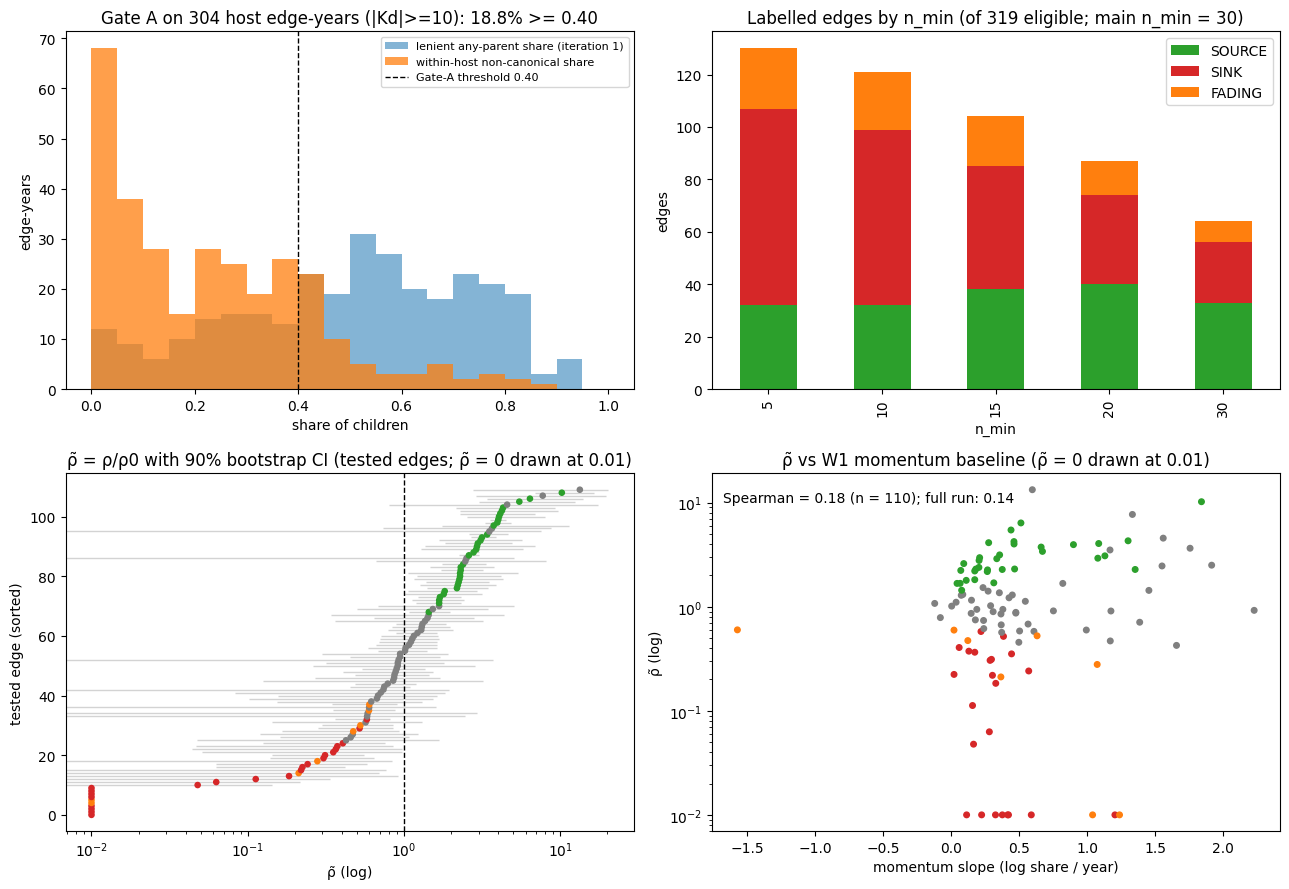

                              phrase    d    t  n_children  n_parents   rho  rho0 rho0_level  rho_tilde  rho_tilde_lo  rho_tilde_hi     m  m_lo  q_greater  q_less state_main
                    dantzig selector 2206 2012          39          6 1.686 0.399         L3      4.229         2.296         9.590 0.201 0.094      0.002   1.000     SOURCE
                    dantzig selector 2206 2013          49         18 0.881 0.404         L3      2.179         1.411         3.462 0.214 0.118      0.006   0.995     SOURCE
                     klein tunneling 3107 2015          45         26 0.335 0.561         L3      0.596         0.353         0.881 0.475 0.315      0.984   0.017     FADING
         convolutional sparse coding 2206 2019          55          5 1.231 0.329         L4      3.746         1.737        11.381 0.297 0.220      0.014   0.996     SOURCE
                          polar code 1702 2014          36          3 0.000 0.130         L2      0.000         0.000         0.00

In [19]:
host = pd.read_parquet(RESULTS / "gate_a" / "gate_a_host_edges.parquet")
k10 = host[host.n_children >= 10]
tested = vl[vl.tested_main]
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# (a) Gate A: within-host share vs the lenient any-parent share on the same edges
bins = np.linspace(0, 1, 21)
ax[0, 0].hist(k10.lenient_share.dropna(), bins=bins, alpha=.55, label="lenient any-parent share (iteration 1)")
ax[0, 0].hist(k10.within_host_share.dropna(), bins=bins, alpha=.75, label="within-host non-canonical share")
ax[0, 0].axvline(0.40, color="k", ls="--", lw=1, label="Gate-A threshold 0.40")
ax[0, 0].set(title=f"Gate A on {len(k10)} host edge-years (|Kd|>=10): {gv['share_edges_ge_040']:.1%} >= 0.40",
             xlabel="share of children", ylabel="edge-years")
ax[0, 0].legend(fontsize=8)

# (b) state counts, main labels and the n_min curve
cols = ["SOURCE", "SINK", "FADING"]
nm = [5, 10, 15, 20, 30]
curve = pd.DataFrame({k: [(vl[f"state_nmin{k}"] == s).sum() for s in cols] for k in nm}, index=cols).T
curve.plot(kind="bar", stacked=True, ax=ax[0, 1], color=["tab:green", "tab:red", "tab:orange"])
ax[0, 1].set(title=f"Labelled edges by n_min (of {len(vl)} eligible; main n_min = {vs['n_min']['n_min_main']})",
             xlabel="n_min", ylabel="edges")

# (c) rho~ with bootstrap CI for tested edges
if len(tested):
    t2 = tested.sort_values("rho_tilde").reset_index(drop=True)
    colr = t2.state_main.map({"SOURCE": "tab:green", "SINK": "tab:red", "FADING": "tab:orange", "UNDETERMINED": "grey"})
    yy = np.arange(len(t2))
    lo = np.clip(t2.rho_tilde - t2.rho_tilde_lo.fillna(t2.rho_tilde), 0, None)
    hi = np.clip(t2.rho_tilde_hi.fillna(t2.rho_tilde) - t2.rho_tilde, 0, None)
    ax[1, 0].errorbar(t2.rho_tilde.clip(lower=1e-2), yy, xerr=[lo, hi], fmt="none", ecolor="lightgrey", lw=1)
    ax[1, 0].scatter(t2.rho_tilde.clip(lower=1e-2), yy, c=colr, s=14, zorder=3)
    ax[1, 0].axvline(1, color="k", ls="--", lw=1)
    ax[1, 0].set_xscale("log")
ax[1, 0].set(title="ρ̃ = ρ/ρ0 with 90% bootstrap CI (tested edges; ρ̃ = 0 drawn at 0.01)", xlabel="ρ̃ (log)", ylabel="tested edge (sorted)")

# (d) rho~ vs W1 momentum (baseline comparison)
if len(tested):
    ok = tested.rho_tilde.notna() & tested.mom.notna()
    ax[1, 1].scatter(tested.mom[ok], tested.rho_tilde[ok].clip(lower=1e-2),
                     c=tested.state_main[ok].map({"SOURCE": "tab:green", "SINK": "tab:red", "FADING": "tab:orange",
                                                  "UNDETERMINED": "grey"}), s=16)
    ax[1, 1].set_yscale("log")
    from scipy.stats import spearmanr
    if ok.sum() >= 3:
        r = spearmanr(tested.rho_tilde[ok], tested.mom[ok])
        ax[1, 1].text(0.02, 0.95, f"Spearman = {r.statistic:.2f} (n = {ok.sum()}); full run: 0.14",
                      transform=ax[1, 1].transAxes, va="top")
ax[1, 1].set(title="ρ̃ vs W1 momentum baseline (ρ̃ = 0 drawn at 0.01)", xlabel="momentum slope (log share / year)", ylabel="ρ̃ (log)")
plt.tight_layout()
plt.show()

show = ["phrase", "d", "t", "n_children", "n_parents", "rho", "rho0", "rho0_level", "rho_tilde", "rho_tilde_lo",
        "rho_tilde_hi", "m", "m_lo", "q_greater", "q_less", "state_main"]
print(tested[tested.state_main != "UNDETERMINED"][show].round(3).to_string(index=False))

## Takeaways

- **Gate A.** The strict within-host, non-canonical traced share is far below the lenient any-parent share on the same edges. Most of what iteration 1 counted as "host transmission" traces back to the origin subfield or to canonical papers, not to earlier host papers. In the full corpus only 17.3% of edges clear 0.40, so every downstream label is **descriptive only**.
- **Viability layer.** Most eligible edges are too small to test (`|Kd| < n_min = 30`). The labels that do appear are mostly SOURCE. In the full run's synthetic validation SOURCE was the only reliable state (FDR 0.13), while SINK (0.40) and FADING (0.28) were not.
- To reproduce the full numbers, run the original `method.py all` on the full iteration-1 corpus with `B = 1000`. This takes about 25 minutes on 4 CPUs.